# Deep Dive: Orchestrator-Worker Multi-Agent Pattern (Dynamic Worker Count)

## Problem card

- **User/trigger:** an on-call engineer opens an incident ticket describing symptoms
  observed across an e-commerce platform (e.g. "checkout is failing" or "search is slow
  and users can't log in").
- **Inputs:** one free-text incident ticket. Under the hood, up to five independent
  services could be implicated: `checkout`, `payments`, `search`, `inventory`, `auth` --
  each with its own synthetic metrics/log tools.
- **Output:** one ranked root-cause report, built only from the services that were
  actually investigated.
- **Success criteria:** the graph investigates *exactly* the services plausibly
  implicated by the ticket -- no more (wasted work/cost), no fewer (missed cause) -- and
  each investigation runs independently and in parallel.
- **Topology:** **orchestrator-worker**, where the orchestrator's job is not just to pick
  *which* worker handles a request (that's routing -- see
  `01_supervisor_orchestrator_worker.ipynb`), and not to fan out over a *fixed, known*
  set of items (that's static fan-out -- see `02_parallel_fan_out_fan_in.ipynb`). Here the
  orchestrator plans a **dynamic number** of workers at runtime, from zero to five,
  based on what the specific ticket actually says.

## Why this is a genuinely different pattern from notebooks 01 and 02

| | `01_supervisor_orchestrator_worker` | `02_parallel_fan_out_fan_in` | **This notebook** |
|---|---|---|---|
| Who decides what runs | Supervisor picks **one** domain out of three | Caller already knows **all four** documents up front | Orchestrator **plans** how many and which services, per ticket |
| Worker count | Always 1 | Always 4 (fixed) | **Varies 1-5**, decided by an LLM call reading the ticket |
| What varies between runs | Which domain is picked | Nothing -- same 4 workers every run | **How many** workers spawn, and which ones |
| LangGraph mechanism | Conditional edge to one node | Static list -> `Send` per item | LLM structured output -> **dynamic-length** list of `Send` |

This distinction is the entire point of "orchestrator-worker" as its own pattern: the
orchestrator is doing real planning work (deciding the *shape* of the parallel work),
not just routing to a pre-known destination or fanning out over an already-fixed list.

In [1]:
import os
import warnings
import logging
from dotenv import load_dotenv, find_dotenv

warnings.filterwarnings("ignore")

load_dotenv(find_dotenv(usecwd=True))
PROVIDER = os.getenv("PROVIDER", "openai").lower()
ANTHROPIC_MODEL = os.getenv("ANTHROPIC_MODEL", "claude-sonnet-5")
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI

import sys
sys.path.insert(0, os.getcwd())
import shared  # shared eval helpers -- ScorecardCallback, Timer, estimate_cost_usd, etc.

scorecard = shared.ScorecardCallback()


def get_llm(temperature: float = 0.0):
    if PROVIDER == "anthropic":
        key = os.getenv("ANTHROPIC_API_KEY")
        if not key:
            raise RuntimeError("PROVIDER=anthropic but ANTHROPIC_API_KEY is not set.")
        return ChatAnthropic(model=ANTHROPIC_MODEL, temperature=temperature, callbacks=[scorecard])
    key = os.getenv("OPENAI_API_KEY")
    if not key:
        raise RuntimeError("PROVIDER=openai but OPENAI_API_KEY is not set.")
    return ChatOpenAI(model=OPENAI_MODEL, temperature=temperature, callbacks=[scorecard])


print(f"Provider: {PROVIDER}, model: {ANTHROPIC_MODEL if PROVIDER == 'anthropic' else OPENAI_MODEL}")

Provider: openai, model: gpt-4o-mini


## The abstract pattern

```mermaid
flowchart TD
    T[Incident ticket] --> O["Orchestrator\n(plans WHICH and HOW MANY services\nare implicated -- 0 to 5)"]
    O -->|dynamic Send x N| W1[Worker: service A]
    O -->|dynamic Send x N| W2[Worker: service B]
    O -->|dynamic Send x N| W3[Worker: service ...N]
    W1 --> S[Synthesizer\nmerges N findings into one report]
    W2 --> S
    W3 --> S
    S --> R[Ranked root-cause report]

    style O fill:#f9c74f,stroke:#333
    style S fill:#90be6d,stroke:#333
```

The number of `Worker` boxes above is not fixed in the diagram on purpose -- it is
whatever the orchestrator decides for *this* ticket. This notebook proves that by
running three different tickets through the exact same compiled graph and showing a
different worker count spawn each time.

## The service pool and its synthetic telemetry

Five independent services, each with its own local synthetic metrics + logs -- no real
infrastructure, no paid APIs. A worker assigned to one service only ever sees that
service's data, mirroring how a real on-call investigator would only be paged for their
own service.

In [2]:
from langchain_core.tools import tool

SERVICE_POOL = ["checkout", "payments", "search", "inventory", "auth"]

# Synthetic, deliberately varied telemetry: some services are clearly healthy (a
# worker assigned there should report "not implicated"), some show a clear fault.
_METRICS = {
    "checkout":  {"error_rate_pct": 18.4, "latency_p99_ms": 2400, "recent_deploy": "checkout-svc v2.14.0, 40 min ago"},
    "payments":  {"error_rate_pct": 22.1, "latency_p99_ms": 950,  "recent_deploy": "payments-svc v1.9.2, 3 days ago"},
    "search":    {"error_rate_pct": 0.3,  "latency_p99_ms": 6100, "recent_deploy": "search-svc v3.2.0, 25 min ago"},
    "inventory": {"error_rate_pct": 0.4,  "latency_p99_ms": 210,  "recent_deploy": "inventory-svc v1.4.1, 6 days ago"},
    "auth":      {"error_rate_pct": 9.7,  "latency_p99_ms": 480,  "recent_deploy": "auth-svc v2.0.3, 2 hours ago"},
}

_LOGS = {
    "checkout":  ["ERROR PaymentGatewayTimeout after 5000ms on order finalize",
                  "ERROR CartLockConflict: retrying order #88213",
                  "WARN checkout-svc: elevated 5xx rate since 14:02 UTC, correlates with v2.14.0 rollout"],
    "payments":  ["ERROR CardAuthDeclined: issuer_timeout for 41% of attempts in last 10m",
                  "ERROR UpstreamGatewayUnavailable: acquirer-bank-3 returning 503",
                  "INFO payments-svc: no recent deploy correlated with spike"],
    "search":    ["WARN search-svc: query latency p99 6.1s (baseline 400ms)",
                  "ERROR IndexShardTimeout on shard-7 after v3.2.0 rollout",
                  "INFO search-svc: error rate normal, this looks latency-only"],
    "inventory": ["INFO inventory-svc: all health checks green",
                  "INFO inventory-svc: stock sync job completed on schedule",
                  "INFO no anomalies in last 60 minutes"],
    "auth":      ["ERROR SSOTokenValidationFailed spike after auth-svc v2.0.3 (2h ago)",
                  "ERROR MFAProviderTimeout for 9.7% of login attempts",
                  "WARN auth-svc: correlates with recent deploy 2 hours ago"],
}


def make_service_tools(service: str):
    """Returns a pair of tools scoped to exactly one service via closure -- a
    worker assigned to `search` physically cannot call `payments`'s tools, because
    it is never given them."""

    @tool(
        f"get_{service}_metrics",
        description=f"Get current error rate, p99 latency, and last deploy info for the {service} service.",
    )
    def get_metrics() -> dict:
        return _METRICS[service]

    @tool(
        f"search_{service}_logs",
        description=f"Search recent {service} service logs, optionally filtered by keyword.",
    )
    def search_logs(keyword: str = "") -> list[str]:
        lines = _LOGS[service]
        if keyword:
            return [l for l in lines if keyword.lower() in l.lower()] or ["No matching log lines."]
        return lines

    return [get_metrics, search_logs]


print(f"Service pool: {SERVICE_POOL}")

Service pool: ['checkout', 'payments', 'search', 'inventory', 'auth']


## Incident dataset

Three tickets, deliberately spanning the full range of the pool -- one service, a
middle subset, and all five -- so the same graph visibly spawns a different number of
workers on each run.

In [3]:
INCIDENTS = [
    {
        "id": "INC-1",
        "ticket": "Search results are extremely slow for all users since about 25 minutes ago. "
                   "No one is reporting errors, just slowness.",
        "expected_services": {"search"},
    },
    {
        "id": "INC-2",
        "ticket": "We're seeing a spike in failed checkouts during the flash sale, and several "
                   "customers report their card was declined even though their bank confirms funds "
                   "are available.",
        "expected_services": {"checkout", "payments"},
    },
    {
        "id": "INC-3",
        "ticket": "Multiple reports coming in: users can't log in at all, and the few who are "
                   "logged in say checkout fails, product search returns nothing, and stock counts "
                   "on the product pages look wrong.",
        "expected_services": {"auth", "checkout", "search", "inventory"},
    },
]

for inc in INCIDENTS:
    print(f"{inc['id']}: {inc['ticket'][:90]}...")

INC-1: Search results are extremely slow for all users since about 25 minutes ago. No one is repo...
INC-2: We're seeing a spike in failed checkouts during the flash sale, and several customers repo...
INC-3: Multiple reports coming in: users can't log in at all, and the few who are logged in say c...


## Graph state

`findings` uses `operator.add` as its reducer -- required for fan-in: every parallel
worker branch appends its own single-item list, and LangGraph merges them all into one
list once every branch completes, instead of one branch overwriting another's result.

In [4]:
import operator
from typing import Annotated, TypedDict


class IncidentState(TypedDict, total=False):
    ticket: str
    implicated_services: list[str]
    service: str  # only set on a per-worker Send payload, not on the top-level invoke
    findings: Annotated[list[dict], operator.add]
    report: str

## Orchestrator node: plans WHICH and HOW MANY workers to spawn

This is the node that makes this an *orchestrator*-worker pattern rather than a router:
it uses structured output to decide a **variable-length** subset of the service pool,
grounded in the ticket text, not a fixed destination.

In [5]:
from pydantic import BaseModel, Field


class IncidentPlan(BaseModel):
    implicated_services: list[str] = Field(
        description=(
            "Subset of ['checkout','payments','search','inventory','auth'] plausibly "
            "implicated by the ticket. Only include a service if the ticket gives a "
            "real signal for it -- do not include services 'just in case'."
        )
    )
    reasoning: str = Field(description="One sentence on why these services and not others.")


ORCHESTRATOR_SYSTEM = f"""You are an incident-triage orchestrator for an e-commerce platform.
The service pool is exactly: {SERVICE_POOL}.
Read the incident ticket and decide which services are plausibly implicated -- this can be
as few as one service or as many as all five, depending on what the ticket actually says.
Do not guess extra services beyond what the ticket supports; under-scoping is also a failure."""


def orchestrator_node(state: IncidentState) -> dict:
    llm = get_llm(temperature=0.0).with_structured_output(IncidentPlan)
    plan: IncidentPlan = llm.invoke([
        {"role": "system", "content": ORCHESTRATOR_SYSTEM},
        {"role": "user", "content": state["ticket"]},
    ])
    services = [s for s in plan.implicated_services if s in SERVICE_POOL]
    return {"implicated_services": services}

## Dynamic fan-out: turning the orchestrator's plan into N parallel `Send`s

This is the mechanism that actually varies the worker count at runtime. `Send` lets a
single conditional-edge function return a **list whose length is decided at graph-run
time**, one entry per implicated service -- as opposed to a normal conditional edge,
which always picks exactly one next node.

In [6]:
from langgraph.types import Send


def dispatch_to_workers(state: IncidentState):
    services = state["implicated_services"]
    if not services:
        # No service plausibly implicated -- skip straight to the synthesizer with an
        # empty findings list rather than force a worker to run on nothing.
        return "synthesizer"
    return [
        Send("investigate_worker", {"ticket": state["ticket"], "service": s})
        for s in services
    ]

## Worker node: one isolated investigation per implicated service

Each worker invocation only receives its own `service` and the ticket -- it cannot see
other workers' findings and cannot call another service's tools, so branches are
genuinely independent (the same isolation property notebook 02 established for static
fan-out, now combined with a dynamic branch count).

In [7]:
WORKER_SYSTEM_TEMPLATE = """You are an on-call investigator for the {service} service only.
Use your tools to check {service}'s current metrics and recent logs, then decide whether
{service} is actually implicated in the incident described, and if so, your best-guess
likely cause."""


class ServiceFinding(BaseModel):
    service: str
    implicated: bool = Field(description="Did this service's own data actually support being implicated?")
    likely_cause: str
    confidence: float = Field(ge=0.0, le=1.0)
    evidence: str


def investigate_worker(state: IncidentState) -> dict:
    service = state["service"]
    tools = make_service_tools(service)
    llm = get_llm(temperature=0.0).bind_tools(tools)

    messages = [
        {"role": "system", "content": WORKER_SYSTEM_TEMPLATE.format(service=service)},
        {"role": "user", "content": state["ticket"]},
    ]
    ai_msg = llm.invoke(messages)
    messages.append(ai_msg)

    tools_by_name = {t.name: t for t in tools}
    for call in getattr(ai_msg, "tool_calls", []) or []:
        result = tools_by_name[call["name"]].invoke(call["args"])
        messages.append({"role": "tool", "content": str(result), "tool_call_id": call["id"]})

    structured_llm = get_llm(temperature=0.0).with_structured_output(ServiceFinding)
    finding: ServiceFinding = structured_llm.invoke(
        messages + [{"role": "user", "content": "Summarize your finding for this service now."}]
    )
    return {"findings": [finding.model_dump()]}

## Synthesizer node: fan-in, merging N findings into one report

LangGraph automatically waits for every `Send`-spawned `investigate_worker` branch to
finish before running `synthesizer`, since every branch's outgoing edge points here --
no manual join/barrier logic needed.

In [8]:
SYNTHESIZER_SYSTEM = """You are writing the final incident root-cause report for an on-call
engineer. You are given per-service findings (possibly zero, if no service was implicated).
Rank services that were actually implicated by confidence, state the most likely root cause
first, and explicitly say if a service was checked but ruled out."""


def synthesizer_node(state: IncidentState) -> dict:
    findings = state.get("findings", [])
    llm = get_llm(temperature=0.0)
    if not findings:
        return {"report": "No services were plausibly implicated by this ticket; no investigation was run."}

    findings_text = "\n".join(
        f"- {f['service']}: implicated={f['implicated']}, confidence={f['confidence']:.2f}, "
        f"cause={f['likely_cause']}, evidence={f['evidence']}"
        for f in findings
    )
    report = llm.invoke([
        {"role": "system", "content": SYNTHESIZER_SYSTEM},
        {"role": "user", "content": f"Ticket: {state['ticket']}\n\nFindings:\n{findings_text}"},
    ])
    return {"report": report.content}

## Assembling the graph

In [9]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(IncidentState)
builder.add_node("orchestrator", orchestrator_node)
builder.add_node("investigate_worker", investigate_worker)
builder.add_node("synthesizer", synthesizer_node)

builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator", dispatch_to_workers, ["investigate_worker", "synthesizer"])
builder.add_edge("investigate_worker", "synthesizer")
builder.add_edge("synthesizer", END)

incident_app = builder.compile()
print("Graph compiled.")

Graph compiled.


## The actual compiled graph

This is `incident_app.get_graph().draw_mermaid()`'s real output, pasted statically so it
renders even without executing this notebook (e.g. viewing it on GitHub) -- the code cell
below regenerates it live and will match exactly:

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	orchestrator(orchestrator)
	investigate_worker(investigate_worker)
	synthesizer(synthesizer)
	__end__([<p>__end__</p>]):::last
	__start__ --> orchestrator;
	investigate_worker --> synthesizer;
	orchestrator -.-> investigate_worker;
	orchestrator -.-> synthesizer;
	synthesizer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc
```

Note it shows the *structure* (one `investigate_worker` node, fanned into by the
conditional edge -- the dashed lines -- fanning out to `synthesizer`), while the actual
*count* of parallel branches at runtime is decided by `dispatch_to_workers` each time the
graph runs, which a static diagram can't show -- that's exactly why the three runs below
matter.

In [10]:
print(incident_app.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	orchestrator(orchestrator)
	investigate_worker(investigate_worker)
	synthesizer(synthesizer)
	__end__([<p>__end__</p>]):::last
	__start__ --> orchestrator;
	investigate_worker --> synthesizer;
	orchestrator -.-> investigate_worker;
	orchestrator -.-> synthesizer;
	synthesizer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



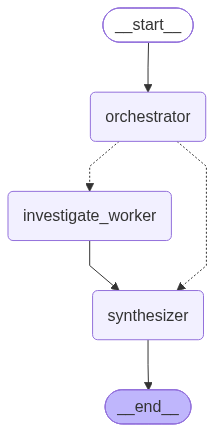

In [11]:
from IPython.display import Image, display

try:
    display(Image(incident_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Skipping PNG render (needs network access to mermaid.ink): {e}")

## Running all three incidents through the same compiled graph

Same `incident_app`, same code path -- only the ticket text changes. Watch
`implicated_services` and the worker count change with it.

In [12]:
results = []
for inc in INCIDENTS:
    scorecard.reset()
    with shared.Timer() as t:
        out = incident_app.invoke({"ticket": inc["ticket"]})
    results.append({
        "id": inc["id"],
        "ticket": inc["ticket"],
        "implicated_services": out["implicated_services"],
        "worker_count": len(out["implicated_services"]),
        "expected_services": inc["expected_services"],
        "findings": out.get("findings", []),
        "report": out["report"],
        "elapsed_s": t.elapsed_s,
        "llm_calls": scorecard.call_count,
    })
    print(f"{inc['id']}: {len(out['implicated_services'])} worker(s) spawned -> {out['implicated_services']}")

INC-1: 1 worker(s) spawned -> ['search']


INC-2: 2 worker(s) spawned -> ['checkout', 'payments']


INC-3: 4 worker(s) spawned -> ['auth', 'checkout', 'search', 'inventory']


In [13]:
for r in results:
    print("=" * 90)
    print(f"{r['id']}  |  workers spawned: {r['worker_count']}  |  services: {r['implicated_services']}")
    print(f"ticket: {r['ticket']}")
    print(f"\nREPORT:\n{r['report']}")
    print()

INC-1  |  workers spawned: 1  |  services: ['search']
ticket: Search results are extremely slow for all users since about 25 minutes ago. No one is reporting errors, just slowness.

REPORT:
**Final Incident Root-Cause Report**

**Incident Summary:**
- **Ticket:** Search results are extremely slow for all users since about 25 minutes ago. No one is reporting errors, just slowness.

**Impacted Services:**
1. **Search**
   - **Implicated:** Yes
   - **Confidence Level:** 0.80
   - **Most Likely Root Cause:** Recent deployment may have introduced performance issues leading to increased latency.
   - **Evidence:** Latency at the 99th percentile is 6100 ms, which indicates significant slowness, and a recent deployment occurred 25 minutes ago.

**Conclusion:**
The primary service implicated in the incident is the Search service, with a high confidence level indicating that the recent deployment is likely the root cause of the performance issues experienced by users. No other services were che

## Proof the worker count is genuinely dynamic

If this were a static fan-out (like notebook 02), every row below would show the same
count. It doesn't.

In [14]:
print(f"{'Incident':<10}{'Workers spawned':<18}{'Services':<45}{'Matches expected?'}")
print("-" * 100)
for r in results:
    matches = set(r["implicated_services"]) == r["expected_services"]
    print(f"{r['id']:<10}{r['worker_count']:<18}{str(r['implicated_services']):<45}{'yes' if matches else 'no'}")

Incident  Workers spawned   Services                                     Matches expected?
----------------------------------------------------------------------------------------------------
INC-1     1                 ['search']                                   yes
INC-2     2                 ['checkout', 'payments']                     yes
INC-3     4                 ['auth', 'checkout', 'search', 'inventory']  yes


## Explain like I'm 12

Imagine you're the team captain and something's wrong with your school's science fair
project. You don't automatically send all five of your teammates to check every part --
that would waste everyone's time if it's just the battery that's broken. And you don't
always send exactly two people either, even when the problem is something else entirely.
Instead, you first *listen* to what's actually broken, then send exactly the right number
of teammates to check exactly the right parts -- maybe just one, maybe all five, it
depends on what's actually wrong. That "first listen, then decide how many people to
send" step is the orchestrator. The teammates who go check their one assigned part are
the workers, and they all report back to you (the synthesizer) so you can explain to the
teacher what's really going on.

## Checkpoint questions

1. **Q: What's the structural difference between this notebook's `dispatch_to_workers`
   and notebook 02's dispatch function?**
   A: Notebook 02's dispatch always returns a `Send` for each of four already-known
   documents -- the list length is fixed before the graph ever runs. This notebook's
   `dispatch_to_workers` returns a list whose length depends on `state["implicated_services"]`,
   which itself was decided by an LLM call reading the specific ticket -- the length is
   only known at runtime, and varies per invocation.

2. **Q: Why does `IncidentState.findings` need `Annotated[list[dict], operator.add]`
   instead of a plain `list[dict]`?**
   A: Multiple `investigate_worker` branches run in parallel and each returns its own
   partial state update. Without a reducer, the last branch to finish would overwrite
   every earlier branch's `findings` update; `operator.add` tells LangGraph to
   concatenate each branch's single-item list into the shared list instead.

3. **Q: What happens if the orchestrator decides zero services are implicated?**
   A: `dispatch_to_workers` returns the plain string `"synthesizer"` instead of a list of
   `Send`s, skipping worker investigation entirely -- the synthesizer then reports that
   no services were implicated rather than crashing on an empty fan-out.

4. **Q: Why does each worker get its own tools via `make_service_tools(service)` instead
   of one shared tool that takes a `service` argument?**
   A: A closure-scoped tool means the LLM literally cannot call another service's data --
   the tool name itself (`get_search_metrics` vs `get_payments_metrics`) only exists for
   that one worker's invocation, which is a stronger boundary than trusting the model to
   pass the correct `service` argument to a shared tool.

## Standardized Multi-Agent Scorecard

Same shape as every other notebook in this series (`shared.py` helpers), captured from
this notebook's own three real runs above, not recomputed separately. Because worker
count varies per incident here, cost/latency are reported per-incident rather than as one
blended average -- collapsing them into a single number would hide the exact behavior
this notebook exists to demonstrate.

In [15]:
model_name = ANTHROPIC_MODEL if PROVIDER == "anthropic" else OPENAI_MODEL

print(f"{'Incident':<10}{'Workers':<10}{'LLM calls':<12}{'Latency (s)':<14}{'Est. cost (USD)'}")
print("-" * 70)
total_calls = 0
total_cost = 0.0
for r in results:
    cost = shared.estimate_cost_usd(r["llm_calls"], model_name)
    total_calls += r["llm_calls"]
    total_cost += cost
    print(f"{r['id']:<10}{r['worker_count']:<10}{r['llm_calls']:<12}{r['elapsed_s']:<14.2f}{cost:.4f}")

print("-" * 70)
print(f"{'TOTAL':<10}{'':<10}{total_calls:<12}{'':<14}{total_cost:.4f}")
print()
print("Why LLM calls scale with worker count, not a fixed number: each incident makes 1")
print("orchestrator call + 1 call per worker (tool-calling) + 1 structured-output call per")
print("worker + 1 synthesizer call -- so INC-3 (4 workers) costs meaningfully more than")
print("INC-1 (1 worker), which is the correct, honest tradeoff for investigating a wider")
print("blast radius, not a bug.")

Incident  Workers   LLM calls   Latency (s)   Est. cost (USD)
----------------------------------------------------------------------
INC-1     1         4           6.72          0.0007
INC-2     2         6           8.33          0.0011
INC-3     4         10          10.18         0.0018
----------------------------------------------------------------------
TOTAL               20                        0.0036

Why LLM calls scale with worker count, not a fixed number: each incident makes 1
orchestrator call + 1 call per worker (tool-calling) + 1 structured-output call per
worker + 1 synthesizer call -- so INC-3 (4 workers) costs meaningfully more than
INC-1 (1 worker), which is the correct, honest tradeoff for investigating a wider
blast radius, not a bug.


## Takeaways: when orchestrator-worker (dynamic) fits, and when it doesn't

**Fits when:**
- The number of independent sub-tasks genuinely varies by input, and that number can be
  inferred from the input itself (here: which services a ticket's symptoms implicate).
- Sub-tasks are truly independent -- each worker can run with zero knowledge of the
  others' findings, isolated tools, and isolated failures (one worker erroring shouldn't
  block the rest).
- The cost of investigating a service that turns out not to be implicated is low enough
  to accept the orchestrator being occasionally over- or under-inclusive.

**Does NOT fit when:**
- The set of workers is actually fixed and known ahead of time -- that's notebook 02's
  static fan-out, and adding a planning LLM call on top is pure overhead.
- There's really only ever one destination to pick -- that's notebook 01's supervisor/
  routing pattern, not orchestrator-worker.
- Sub-tasks depend on each other's output (worker B needs worker A's finding first) --
  that calls for a sequential pipeline (notebook 03) or planner-executor (notebook 04)
  instead, since true fan-out requires independence.

**The one line that matters most:** an orchestrator *plans the shape of the work*; a
supervisor *picks a destination*; a static fan-out *already knows the shape*. This
notebook's `dispatch_to_workers` is the only one of the three that decides "how many"
from the actual input, at runtime, every single call.